In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv("mall customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [12]:
df = df.rename(columns = {'Annual Income (k$)' : 'Income', 'Spending Score (1-100)': 'Score'})

In [13]:
df

,CustomerID,Gender,Age,Income,Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [14]:
df.isna().sum()

CustomerID    0
Gender        0
Age           0
Income        0
Score         0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Score       200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [16]:
df['Gender'] =df.Gender.replace({'Male': 0, 'Female': 1})

C:\Users\Qbits\AppData\Local\Temp\ipykernel_5996\3875562678.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] =df.Gender.replace({'Male': 0, 'Female': 1})


In [17]:
df

,CustomerID,Gender,Age,Income,Score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
...,...,...,...,...,...
195,196,1,35,120,79
196,197,1,45,126,28
197,198,0,32,126,74
198,199,0,32,137,18


In [18]:
df.Gender.value_counts()

Gender
1    112
0     88
Name: count, dtype: int64

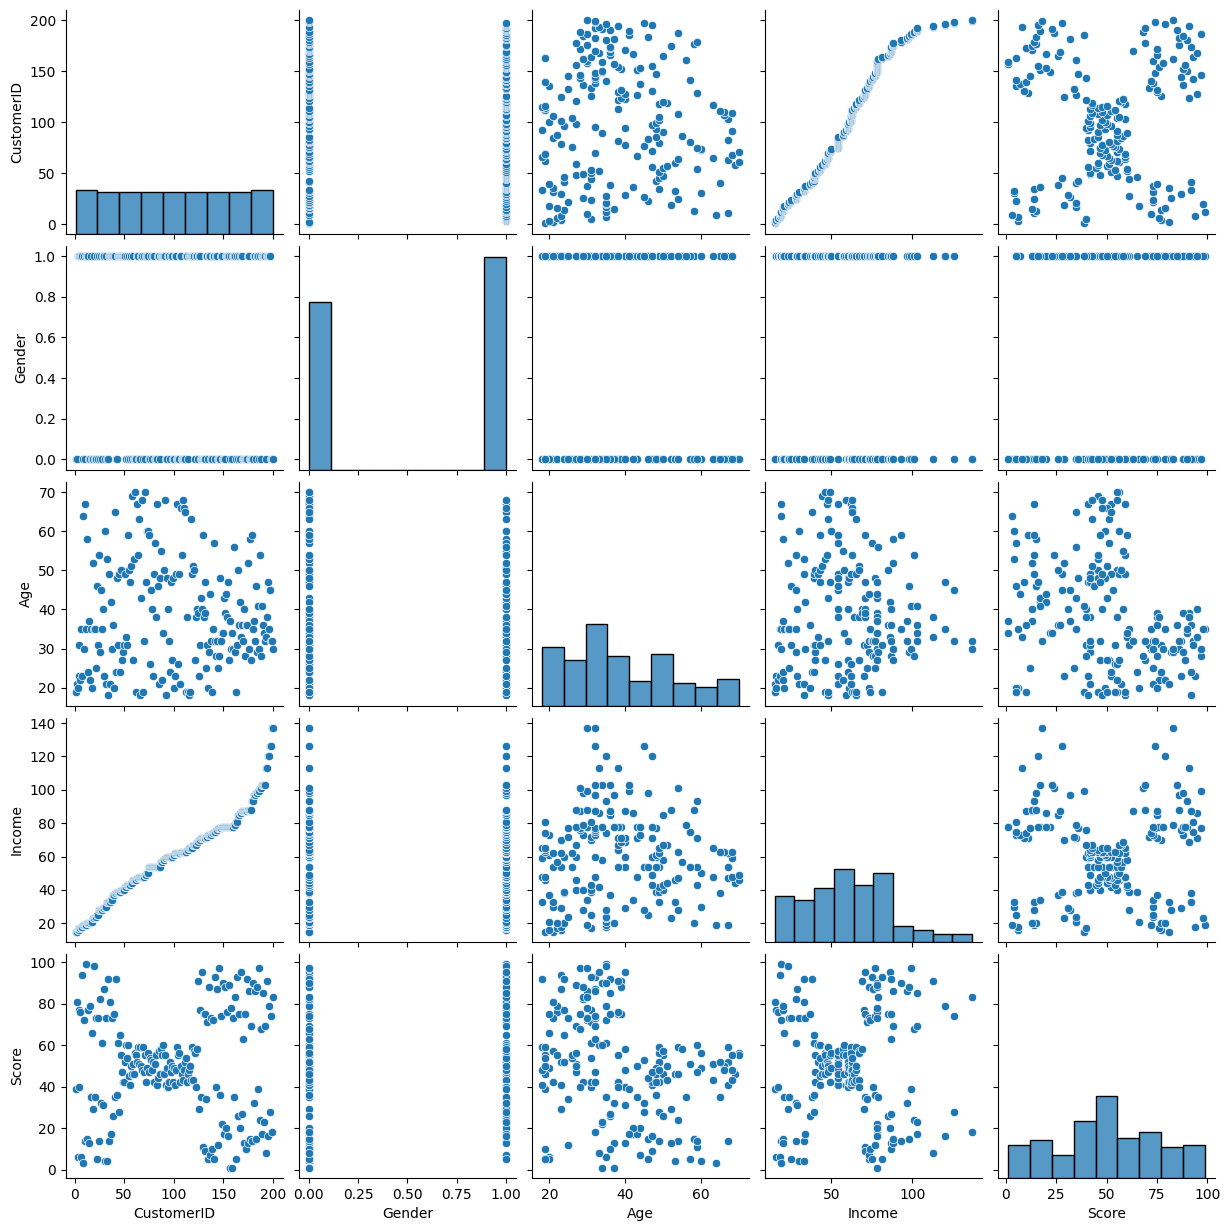

In [19]:
sns.pairplot(df)
plt.show()

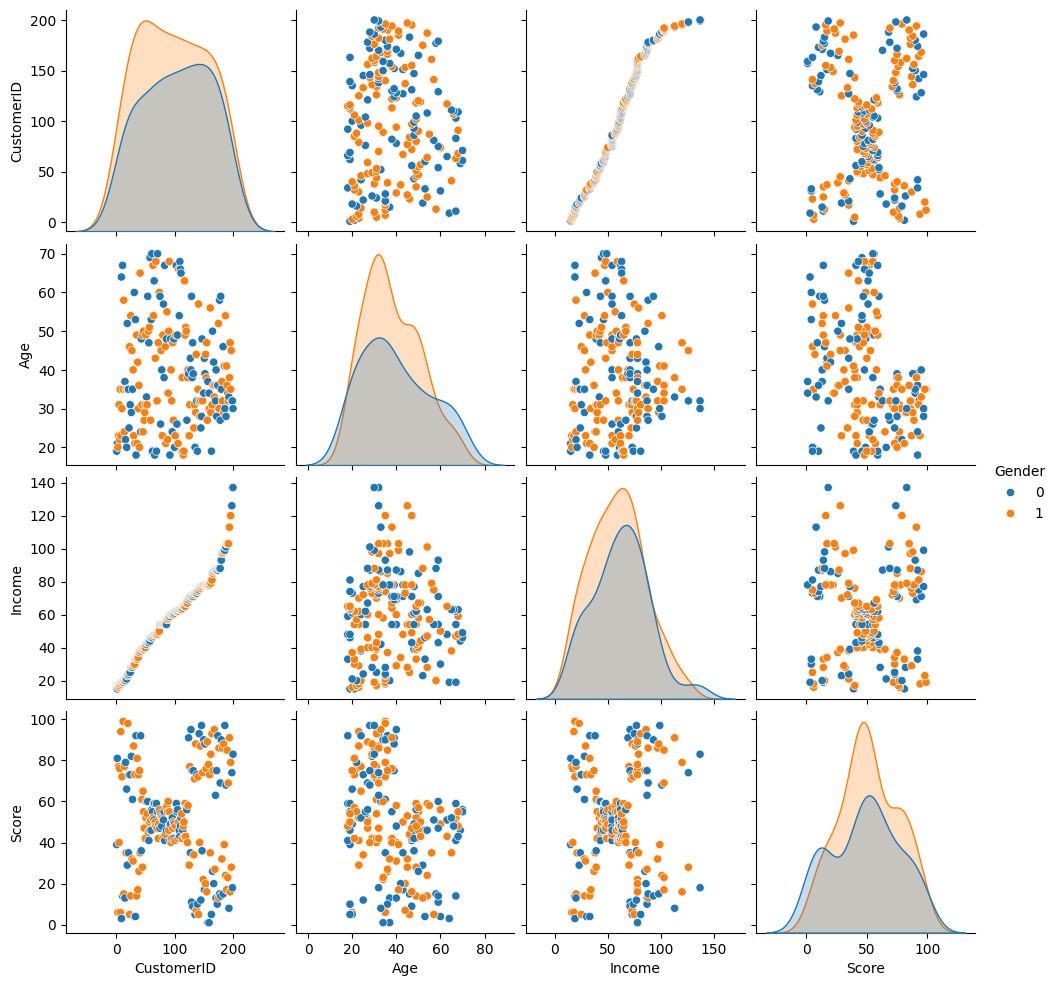

In [20]:
sns.pairplot(df, hue='Gender')
plt.show()

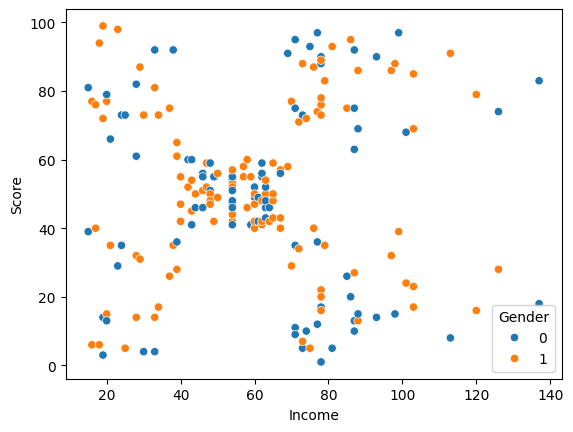

In [22]:
sns.scatterplot(x = df.Income, y = df.Score, hue = df.Gender)
plt.show()

In [24]:
from sklearn.cluster import KMeans
km = KMeans (n_clusters=8)

In [25]:
km.fit(df[['Income',"Score"]])

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [26]:
pred = km.predict(df[['Income',"Score"]])
pred

array([5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4,
       5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 0,
       5, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 6, 7, 6, 7, 3, 7, 3, 7,
       6, 7, 3, 7, 3, 7, 3, 7, 3, 7, 6, 7, 3, 7, 6, 7, 6, 7, 3, 7, 6, 7,
       3, 7, 3, 7, 3, 7, 6, 7, 3, 7, 6, 7, 6, 7, 6, 7, 3, 7, 3, 7, 3, 7,
       6, 7, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [27]:
df['Initial Prediction'] = pred

In [28]:
df

,CustomerID,Gender,Age,Income,Score,Initial Prediction
0,1,0,19,15,39,5
1,2,0,21,15,81,4
2,3,1,20,16,6,5
3,4,1,23,16,77,4
4,5,1,31,17,40,5
...,...,...,...,...,...,...
195,196,1,35,120,79,2
196,197,1,45,126,28,1
197,198,0,32,126,74,2
198,199,0,32,137,18,1


In [30]:
df0 = df[df['Initial Prediction'] == 0]
df1 = df[df['Initial Prediction'] == 1]
df2 = df[df['Initial Prediction'] == 2]
df3 = df[df['Initial Prediction'] == 3]
df4 = df[df['Initial Prediction'] == 4]
df5 = df[df['Initial Prediction'] == 5]
df6 = df[df['Initial Prediction'] == 6]
df7 = df[df['Initial Prediction'] == 7]

In [32]:
center = km.cluster_centers_
center

array([[ 54.61538462,  50.02564103],
       [124.        ,  17.5       ],
       [108.18181818,  82.72727273],
       [ 77.93333333,   9.        ],
       [ 25.72727273,  79.36363636],
       [ 26.30434783,  20.91304348],
       [ 86.36842105,  26.47368421],
       [ 78.03571429,  81.89285714]])

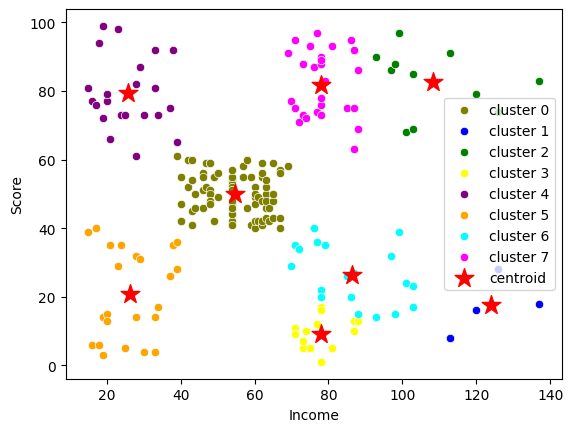

In [38]:
sns.scatterplot(x=df0.Income, y=df0.Score, color='olive', label='cluster 0')
sns.scatterplot(x=df1.Income, y=df1.Score, color='blue', label='cluster 1')
sns.scatterplot(x=df2.Income, y=df2.Score, color='green', label='cluster 2')
sns.scatterplot(x=df3.Income, y=df3.Score, color='yellow', label='cluster 3')
sns.scatterplot(x=df4.Income, y=df4.Score, color='purple', label='cluster 4')
sns.scatterplot(x=df5.Income, y=df5.Score, color='orange', label='cluster 5')
sns.scatterplot(x=df6.Income, y=df6.Score, color='cyan', label='cluster 6')
sns.scatterplot(x=df7.Income, y=df7.Score, color='magenta', label='cluster 7')

plt.scatter(center[:,0], center[:,1], color="red", marker="*", s=200, label="centroid")

plt.legend()
plt.show()

In [68]:
# elbow
wcss = []
cluster = range(1,20)
for i in cluster:
    km2 = KMeans(n_clusters=i)
    km2.fit(df[['Income','Score']])
    wcss.append(km2.inertia_)

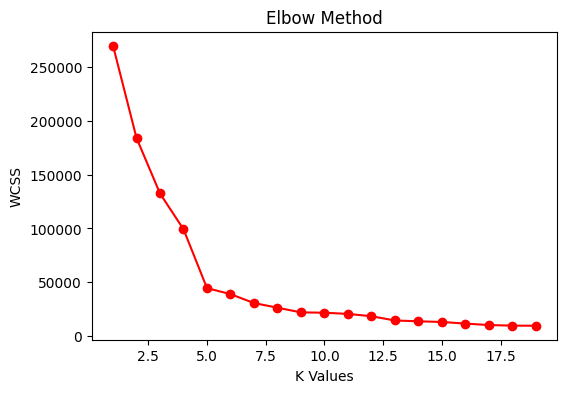

In [69]:
plt.figure(figsize=(6,4))
plt.plot(cluster, wcss, marker = "o", color ="red")
plt.ylabel('WCSS')
plt.xlabel('K Values')
plt.title('Elbow Method')
plt.show()

In [70]:
from kneed import KneeLocator
kn = KneeLocator(cluster, wcss, curve= "convex", direction = "decreasing")

Text(0.5, 0, 'Num of Clusters')

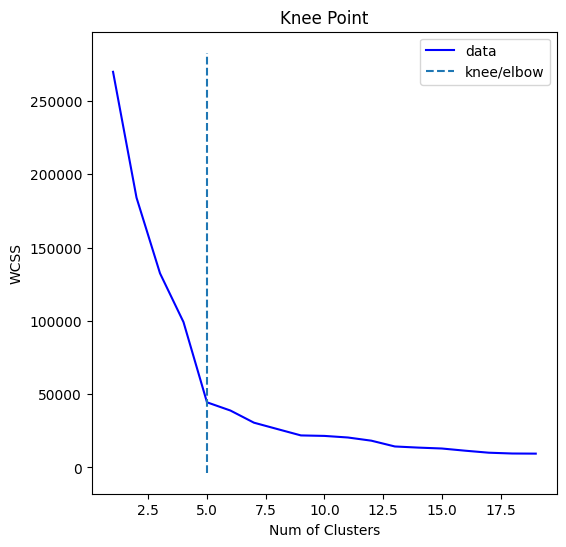

In [71]:
kn.plot_knee()
plt.ylabel('WCSS')
plt.xlabel('Num of Clusters')

In [72]:
km3 = KMeans(n_clusters = 5)
km3.fit(df[['Income',"Score"]])

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [73]:
pred2 = km3.predict(df[['Income',"Score"]])
pred2

array([4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 3,
       4, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 0, 2, 3, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 3, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

In [74]:
df['Final Prediction'] = pred2

In [75]:
df

,CustomerID,Gender,Age,Income,Score,Initial Prediction,Final Prediction
0,1,0,19,15,39,5,4
1,2,0,21,15,81,4,1
2,3,1,20,16,6,5,4
3,4,1,23,16,77,4,1
4,5,1,31,17,40,5,4
...,...,...,...,...,...,...,...
195,196,1,35,120,79,2,2
196,197,1,45,126,28,1,0
197,198,0,32,126,74,2,2
198,199,0,32,137,18,1,0


In [76]:
new_cen = km3.cluster_centers_
new_cen

array([[87.75      , 17.58333333],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513],
       [55.0875    , 49.7125    ],
       [26.30434783, 20.91304348]])

In [77]:
df01 = df[df['Final Prediction'] == 0]
df11 = df[df['Final Prediction'] == 1]
df21 = df[df['Final Prediction'] == 2]
df31 = df[df['Final Prediction'] == 3]
df41 = df[df['Final Prediction'] == 4]

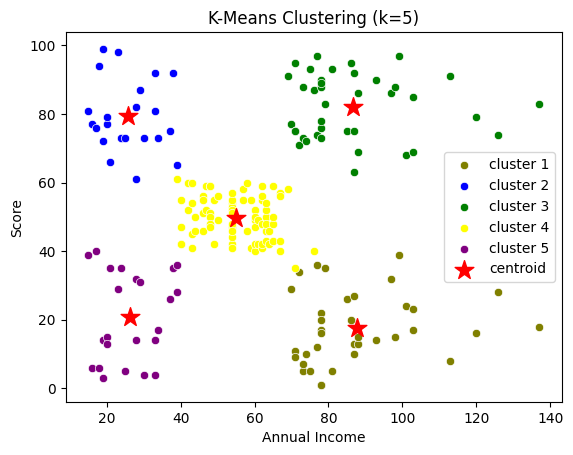

In [78]:
sns.scatterplot(x=df01.Income, y=df01.Score, color='olive', label='cluster 1')
sns.scatterplot(x=df11.Income, y=df11.Score, color='blue', label='cluster 2')
sns.scatterplot(x=df21.Income, y=df21.Score, color='green', label='cluster 3')
sns.scatterplot(x=df31.Income, y=df31.Score, color='yellow', label='cluster 4')
sns.scatterplot(x=df41.Income, y=df41.Score, color='purple', label='cluster 5')


plt.scatter(new_cen[:,0], new_cen[:,1], color="red", marker="*", s=200, label="centroid")
plt.xlabel('Annual Income')
plt.ylabel('Score')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()


# Evaluation

In [81]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(df[['Income', 'Score']])

score = silhouette_score(df[['Income', 'Score']], labels)
print("Silhouette Score:", score)

# Interpretation

# 0.5 → Good

# 0.25–0.5 → Acceptable
# < 0.25 → Poor

Silhouette Score: 0.553931997444648


In [82]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(df[['Income', 'Score']], labels)
print("Davies-Bouldin Index:", db_index)

# Interpretation
# Lower = better
# 0 is ideal (rare in real data)

Davies-Bouldin Index: 0.5725628995597087


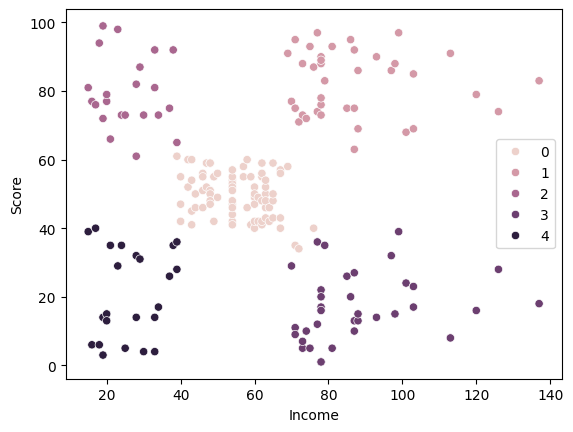

In [83]:
sns.scatterplot(x='Income', y='Score', hue=labels, data=df)
plt.show()